In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

In [5]:
data = pd.read_csv('hospitals.csv')
data_num = data.select_dtypes(include='number')
data_num['Facility.State'] = data['Facility.State']

In [6]:
data.head()

,Facility.Name,Facility.City,Facility.State,Facility.Type,Rating.Overall,Rating.Mortality,Rating.Safety,Rating.Readmission,Rating.Experience,Rating.Effectiveness,...,Procedure.Heart Attack.Value,Procedure.Heart Failure.Cost,Procedure.Heart Failure.Quality,Procedure.Heart Failure.Value,Procedure.Pneumonia.Cost,Procedure.Pneumonia.Quality,Procedure.Pneumonia.Value,Procedure.Hip Knee.Cost,Procedure.Hip Knee.Quality,Procedure.Hip Knee.Value
0,Southeast Alabama Medical Center,Dothan,AL,Government,2,Below,Above,Below,Below,Same,...,Average,17041,Average,Average,18281,Average,Average,25812,Average,Higher
1,Marshall Medical Center South,Boaz,AL,Government,1,Below,Below,Below,Same,Above,...,Average,15819,Worse,Average,15614,Worse,Lower,22747,Average,Average
2,Eliza Coffee Memorial Hospital,Florence,AL,Government,3,Below,Above,Above,Below,Same,...,Average,16334,Average,Average,17371,Average,Average,24491,Average,Higher
3,Mizell Memorial Hospital,Opp,AL,Private,1,Same,Same,Below,Below,Below,...,Unknown,14541,Average,Lower,15226,Worse,Lower,23472,Average,Average
4,Crenshaw Community Hospital,Luverne,AL,Proprietary,4,Same,NaN,Above,NaN,Same,...,Unknown,13767,Average,Lower,14341,Average,Lower,0,Unknown,Unknown


In [7]:
data_num.head()

,Rating.Overall,Procedure.Heart Attack.Cost,Procedure.Heart Failure.Cost,Procedure.Pneumonia.Cost,Procedure.Hip Knee.Cost,Facility.State
0,2,23394,17041,18281,25812,AL
1,1,22579,15819,15614,22747,AL
2,3,24002,16334,17371,24491,AL
3,1,0,14541,15226,23472,AL
4,4,0,13767,14341,0,AL


In [8]:
data_by_state = data_num.groupby(by='Facility.State').aggregate(np.mean) #aggregate drops any NaNs before taking the average
#Index becomes the state (AK, AL, AR...)

/var/folders/6q/z403kbqn59qg1mpwf8xqml5r0000gn/T/ipykernel_80695/3306773899.py:1: FutureWarning: The provided callable <function mean at 0x114db4b80> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data_by_state = data_num.groupby(by='Facility.State').aggregate(np.mean) #aggregate drops any NaNs before taking the average


In [9]:
states = gpd.read_file('usa-states-census-2014.shx')

In [14]:
states.head()

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,region,geometry
0,06,01779778,0400000US06,06,CA,California,00,403483823181,20483271881,West,"MULTIPOLYGON Z (((-118.59397 33.4672 0, -118.4..."
1,11,01702382,0400000US11,11,DC,District of Columbia,00,158350578,18633500,Northeast,"POLYGON Z ((-77.11976 38.93434 0, -77.04102 38..."
2,12,00294478,0400000US12,12,FL,Florida,00,138903200855,31407883551,Southeast,"MULTIPOLYGON Z (((-81.81169 24.56874 0, -81.75..."
3,13,01705317,0400000US13,13,GA,Georgia,00,148963503399,4947080103,Southeast,"POLYGON Z ((-85.60516 34.98468 0, -85.47434 34..."
4,16,01779783,0400000US16,16,ID,Idaho,00,214045425549,2397728105,West,"POLYGON Z ((-117.24303 44.39097 0, -117.21507 ..."


In [10]:
states = states.rename(columns= {'STUSPS': 'Facility.State'})

In [11]:
states.head()

,STATEFP,STATENS,AFFGEOID,GEOID,Facility.State,NAME,LSAD,ALAND,AWATER,region,geometry
0,06,01779778,0400000US06,06,CA,California,00,403483823181,20483271881,West,"MULTIPOLYGON Z (((-118.59397 33.4672 0, -118.4..."
1,11,01702382,0400000US11,11,DC,District of Columbia,00,158350578,18633500,Northeast,"POLYGON Z ((-77.11976 38.93434 0, -77.04102 38..."
2,12,00294478,0400000US12,12,FL,Florida,00,138903200855,31407883551,Southeast,"MULTIPOLYGON Z (((-81.81169 24.56874 0, -81.75..."
3,13,01705317,0400000US13,13,GA,Georgia,00,148963503399,4947080103,Southeast,"POLYGON Z ((-85.60516 34.98468 0, -85.47434 34..."
4,16,01779783,0400000US16,16,ID,Idaho,00,214045425549,2397728105,West,"POLYGON Z ((-117.24303 44.39097 0, -117.21507 ..."


In [12]:
states_Data = states.merge(data_by_state, on='Facility.State', how='left')

In [13]:
states_Data.head()

,STATEFP,STATENS,AFFGEOID,GEOID,Facility.State,NAME,LSAD,ALAND,AWATER,region,geometry,Rating.Overall,Procedure.Heart Attack.Cost,Procedure.Heart Failure.Cost,Procedure.Pneumonia.Cost,Procedure.Hip Knee.Cost
0,06,01779778,0400000US06,06,CA,California,00,403483823181,20483271881,West,"MULTIPOLYGON Z (((-118.59397 33.4672 0, -118.4...",2.364706,14079.597059,12567.961765,15012.900000,12629.926471
1,11,01702382,0400000US11,11,DC,District of Columbia,00,158350578,18633500,Northeast,"POLYGON Z ((-77.11976 38.93434 0, -77.04102 38...",1.125000,20839.375000,14524.750000,16283.750000,14612.875000
2,12,00294478,0400000US12,12,FL,Florida,00,138903200855,31407883551,Southeast,"MULTIPOLYGON Z (((-81.81169 24.56874 0, -81.75...",2.250000,19922.771739,16479.027174,17087.010870,18106.244565
3,13,01705317,0400000US13,13,GA,Georgia,00,148963503399,4947080103,Southeast,"POLYGON Z ((-85.60516 34.98468 0, -85.47434 34...",2.189394,11128.795455,11392.787879,14432.348485,11728.083333
4,16,01779783,0400000US16,16,ID,Idaho,00,214045425549,2397728105,West,"POLYGON Z ((-117.24303 44.39097 0, -117.21507 ...",1.809524,4869.714286,7762.619048,12751.000000,11932.666667


(-127.6146362, -64.0610978, 23.253819649999997, 50.628669349999996)

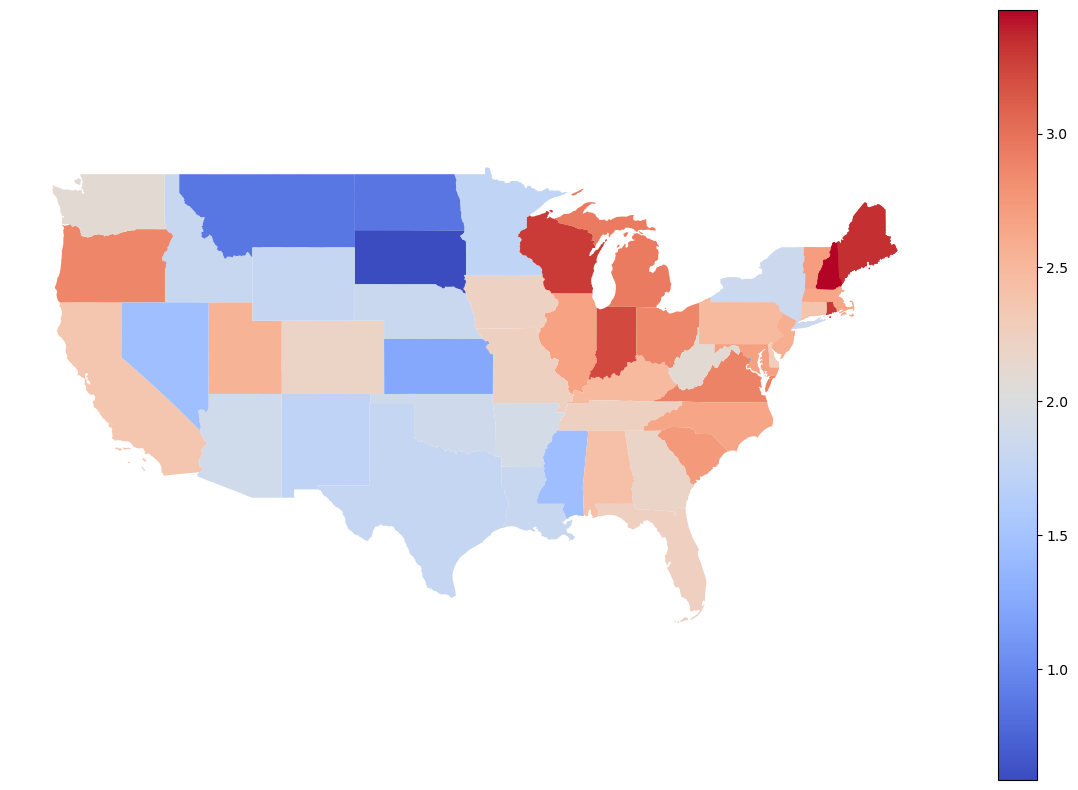

In [19]:
fig, ax = plt.subplots(figsize=(15, 10)) # helps with customization
states_Data.plot(column='Rating.Overall', cmap='coolwarm', ax=ax, legend=True) #ax=ax combines the two plots
ax.axis('off') # removes the axis